# Optical cross-match (NED-LVS + MilliQUAS)

Cross-match the OVRO-LWA **MHz subband** metacatalog against optical catalogs:

| Catalog | Role |
| --- | --- |
| [NED Local Volume Sample](https://ned.ipac.caltech.edu/NED::LVS/) (Cook et al. 2023) | Nearby galaxy hosts (diameter + redshift gate) |
| [MilliQUAS](https://quasars.org/milliquas.htm) (Flesch) | All-sky quasars / AGN with optical class codes |

Prefer `metacatalog_spectral.parquet` from `radio_crossmatch.ipynb` when present so associations use cascaded `match_RA`/`match_DEC` (best bijective VLSSR→NVSS→VLASS position) and survey-appropriate `match_sigma_deg` / `match_source` defaults; otherwise fall back to quality metacatalog `RA`/`DEC` with LWA centroid errors.

Matching gate (degrees): `max(POSITION_SIGMA_SCALE * hypot(σ_meta, σ_ned), DIAM_SCALE * Diam_arcsec)`. `σ_meta` prefers `match_sigma_deg`, else VLSSR/NVSS/VLASS defaults from `match_source`, else LWA `E_RA`/`E_DEC` / `cluster_jitter_rms_deg`. NED-LVS galaxies above `MAX_REDSHIFT` are excluded.

**Primary metric:** fraction of quality-cleared metacatalog rows with a NED-LVS galaxy within that gate.

**SFR–radio plot:** unique matches only (`n_nedlvs == 1`); converts highest-frequency LWA flux (preferring total) to `nu*L_nu` vs NED-LVS SFR.

**Match offsets:** closest-hit and unique 1:1 distributions of projected separation (arcsec, log–log) and physical transverse offset (`θ × DistMpc`).

**Match browser:** interactive table of matched meta↔NED-LVS rows with a DSS sky widget; click a row to recenter, optionally overlay a radio HiPS.

**Size comparison:** unique matches only; metacatalog `Maj` (FWHM, converted to arcsec) vs NED-LVS projected diameter (`Diam_arcsec`).

**82 MHz flux ECDF:** cumulative fraction of sources vs native `Total_flux_82MHz`.

**MilliQUAS:** LWA beam × fixed 1″ optical gate via `associate_catalogs`; attaches `MilliQUAS_Type`, `MilliQUAS_class_primary` / `class_label`, radio/X-ray/lobe flags, redshift, and photometry. Toggle with `RUN_MILLIQUAS_CROSSMATCH`.

**Run cells in order** (NED-LVS first; MilliQUAS reuses `selected_meta`).


In [ ]:
from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog
from lwa_catalog.analyze import (
    CORE_CLEAN_EXCLUDE_MASK,
    LWA_CROSSMATCH_RADIUS_BEAM,
    MILLIQUAS_CLASS_LABELS,
    MILLIQUAS_REFERENCE_RADIUS_FIXED,
    MilliquasMatchConfig,
    NedlvsMatchConfig,
    attach_milliquas_to_metacatalog,
    build_sfr_radio_luminosity_table,
    filter_by_quality_mask,
    load_milliquas_catalog,
    load_nedlvs_catalog,
    match_catalog_to_milliquas,
    match_catalog_to_nedlvs,
    milliquas_class_counts,
    select_metacatalog,
    select_unique_milliquas_matches,
    select_unique_nedlvs_matches,
    summarize_milliquas_match,
    summarize_nedlvs_match,
)
from lwa_catalog.constants import (
    MILLIQUAS_DEFAULT_PATH,
    NEDLVS_DEFAULT_DIAM_SCALE,
    NEDLVS_DEFAULT_PATH,
    SUBBAND_METACATALOG_REQUIRED_COLUMNS,
)
from lwa_catalog.io import read_table, validate_metacatalog

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_healpix_IdTR-0.75s_subband/")
NEDLVS_PATH = NEDLVS_DEFAULT_PATH
MILLIQUAS_PATH = MILLIQUAS_DEFAULT_PATH  # FITS table despite .dat suffix
RUN_MILLIQUAS_CROSSMATCH = True
# Optional primary-class filter, e.g. ("Q", "A", "B"); None keeps all.
MILLIQUAS_CLASSES: tuple[str, ...] | None = None
QUALITY_FLAG_MASK = CORE_CLEAN_EXCLUDE_MASK  # set None to keep all rows
# Prefer metacatalog_spectral.parquet (match_RA/match_DEC/match_source from radio cascade).
USE_SPECTRAL_MATCH_POSITIONS = True

# Metacatalog subset before cross-match:
#   "full" | "blue" | "quality_all_clear" | "query"
# MHz subband catalogs have no Blue band — use "full" (all quality-cleared rows).
METACATALOG_SELECTION = "full"
METACATALOG_QUERY = "Peak_flux_82MHz > 1.0"  # used only when METACATALOG_SELECTION == "query"

# Cross-match gate:
#   max(POSITION_SIGMA_SCALE * hypot(σ_meta, σ_ned), DIAM_SCALE * Diam_arcsec)
POSITION_SIGMA_SCALE = 3.0
DIAM_SCALE = NEDLVS_DEFAULT_DIAM_SCALE  # 0.5; set None to disable galaxy-size floor
MAX_REDSHIFT = 0.5

layout = CatalogLayout(CATALOG_DIR)
# Fusion metacatalog fallback. None → CATALOG_DIR/metacatalog.parquet.
# Example provisional: layout.root / "metacatalog_test.parquet"
METACATALOG_PATH: Path | None = None
INPUT_PATH = METACATALOG_PATH if METACATALOG_PATH is not None else layout.metacatalog()
SPECTRAL_PATH = layout.metacatalog_spectral()
USE_RADIO = bool(USE_SPECTRAL_MATCH_POSITIONS and SPECTRAL_PATH.is_file())
METACATALOG_LOAD_PATH = SPECTRAL_PATH if USE_RADIO else INPUT_PATH
config = NedlvsMatchConfig(
    catalog_path=NEDLVS_PATH,
    target="metacatalog",
    position_sigma_scale=POSITION_SIGMA_SCALE,
    max_redshift=MAX_REDSHIFT,
    diam_scale=DIAM_SCALE,
)
milliquas_config = MilliquasMatchConfig(
    catalog_path=MILLIQUAS_PATH,
    target="metacatalog",
    lwa_radius=LWA_CROSSMATCH_RADIUS_BEAM,
    reference_radius=MILLIQUAS_REFERENCE_RADIUS_FIXED,
    classes=MILLIQUAS_CLASSES,
)

print("CATALOG_DIR =", layout.root.resolve())
print("INPUT_PATH =", INPUT_PATH.resolve())
print("INPUT_PATH exists:", INPUT_PATH.is_file())
print("USE_SPECTRAL_MATCH_POSITIONS =", USE_SPECTRAL_MATCH_POSITIONS)
print("SPECTRAL_PATH =", SPECTRAL_PATH.resolve(), "(exists)" if SPECTRAL_PATH.is_file() else "(missing)")
print("metacatalog load path =", METACATALOG_LOAD_PATH.resolve())
if USE_SPECTRAL_MATCH_POSITIONS and not SPECTRAL_PATH.is_file():
    print("  (radio missing — will fall back to", INPUT_PATH.resolve(), ")")
print("QUALITY_FLAG_MASK =", QUALITY_FLAG_MASK)
print("NEDLVS_PATH =", Path(NEDLVS_PATH).resolve())
print("MILLIQUAS_PATH =", Path(MILLIQUAS_PATH).resolve(),
      "(exists)" if Path(MILLIQUAS_PATH).is_file() else "(missing)")
print("RUN_MILLIQUAS_CROSSMATCH =", RUN_MILLIQUAS_CROSSMATCH)
print("MILLIQUAS_CLASSES =", MILLIQUAS_CLASSES)
print("METACATALOG_SELECTION =", METACATALOG_SELECTION)
print("POSITION_SIGMA_SCALE =", POSITION_SIGMA_SCALE)
print("DIAM_SCALE =", DIAM_SCALE)
print("MAX_REDSHIFT =", MAX_REDSHIFT)
print("MilliQUAS class legend:")
for code, label in MILLIQUAS_CLASS_LABELS.items():
    print(f"  {code}: {label}")


## Load metacatalog

Prefer ``metacatalog_spectral.parquet`` when `USE_SPECTRAL_MATCH_POSITIONS` is set so NED-LVS matching uses cascaded ``match_RA``/``match_DEC`` (and ``match_source`` / ``match_sigma_deg`` when present). Validates required subband columns, then applies `filter_by_quality_mask`. Otherwise reads `INPUT_PATH` (fusion metacatalog; default ``metacatalog.parquet``). Every quality-cleared row is used; there is no Blue-band subset.


In [ ]:
if USE_RADIO:
    metacatalog = read_table(SPECTRAL_PATH, as_pandas=True)
    validate_metacatalog(metacatalog, required=SUBBAND_METACATALOG_REQUIRED_COLUMNS)
    if QUALITY_FLAG_MASK is not None:
        metacatalog = filter_by_quality_mask(metacatalog, QUALITY_FLAG_MASK).reset_index(
            drop=True
        )
    print(f"Loaded radio crossmatch: {SPECTRAL_PATH.resolve()}")
elif USE_SPECTRAL_MATCH_POSITIONS:
    print(f"USE_SPECTRAL_MATCH_POSITIONS=True but missing {SPECTRAL_PATH}; falling back to {INPUT_PATH}.")
    metacatalog = read_metacatalog(
        INPUT_PATH,
        quality_mask=QUALITY_FLAG_MASK,
    )
else:
    metacatalog = read_metacatalog(
        INPUT_PATH,
        quality_mask=QUALITY_FLAG_MASK,
    )

selected_meta = select_metacatalog(
    metacatalog,
    selection=METACATALOG_SELECTION,
    layout=layout,
    query=METACATALOG_QUERY,
)

print(f"metacatalog rows: {len(metacatalog)}")
print(f"selected rows ({METACATALOG_SELECTION}): {len(selected_meta)}")
print(f"quality_flag present: {'quality_flag' in metacatalog.columns}")
print(f"match_RA present: {'match_RA' in selected_meta.columns}")
print(f"match_sigma_deg present: {'match_sigma_deg' in selected_meta.columns}")
if "match_source" in selected_meta.columns:
    print("match_source counts:")
    display(selected_meta["match_source"].astype(str).value_counts())
print(f"spectral columns present: {any(c.startswith('spec_peak_') for c in metacatalog.columns)}")
print(f"Peak_flux_82MHz present: {'Peak_flux_82MHz' in metacatalog.columns}")
print(f"Total_flux_82MHz present: {'Total_flux_82MHz' in metacatalog.columns}")


## Load NED-LVS

Loads ~2.1M rows from the FITS table (takes ~15–30 s on lwacalim09).

In [3]:
nedlvs = load_nedlvs_catalog(NEDLVS_PATH)
print(f"NED-LVS rows: {len(nedlvs):,}")
print(f"rows with Diam: {(nedlvs['Diam_arcsec'] > 0).sum():,}")
nedlvs.head()

NED-LVS rows: 2,103,732
rows with Diam: 1,701,193


,objname,RA,DEC,objtype,z,DistMpc,Mstar,SFR_hybrid,SFR_W4,Diam_arcsec
0,b'WISEA J120155.41+623831.1',180.480897,62.641997,b'G',-0.000509,0.0,NaN,NaN,NaN,NaN
1,b'DESI J252.3925+33.8869',252.392549,33.886965,b'G',-0.000409,0.0,NaN,NaN,NaN,NaN
2,b'WISEA J090812.84+514023.6',137.053538,51.673233,b'IrS',-0.000102,0.0,NaN,NaN,NaN,NaN
3,b'DESI J194.2665+32.1772',194.266570,32.177269,b'G',-0.000922,0.0,NaN,NaN,NaN,NaN
4,b'SDSS J120327.61-015758.7',180.865007,-1.966329,b'G',-0.000043,0.0,NaN,NaN,NaN,NaN


## Cross-match against NED-LVS

Associations use ``match_RA``/``match_DEC`` when present, with σ from ``match_sigma_deg`` or ``match_source`` survey defaults (else LWA centroid errors), floored by ``DIAM_SCALE * Diam_arcsec``. ``meta_flags`` records ``match_*`` and ``centroid_sigma_deg`` for diagnostics.


In [4]:
result = match_catalog_to_nedlvs(selected_meta, nedlvs=nedlvs, config=config)
print(summarize_nedlvs_match(result))

LWA target rows:                167618
NED-LVS footprint (Dec box):    1883163
Meta matched (>=1 NED-LVS):       5284
Meta with NED-LVS host:         0.032
Meta unique match (n=1):          2963
Meta unique fraction:           0.018
NED-LVS matched (>=1 meta):      76943
NED-LVS recovery:               0.041
NED-LVS over-split (n_meta>1):    6724
Meta multi-NED-LVS (n>1):         2321
Max NED-LVS hits per meta:        1627

Warnings:
  - redshift filter z <= 0.5: 3126 NED-LVS rows removed from footprint


## Diagnostics

In [5]:
meta_flags = result.meta_flags
nedlvs_flags = result.nedlvs_flags

print("NED-LVS hits per meta (value_counts):")
display(meta_flags["n_nedlvs"].value_counts().sort_index())

print("\nMeta rows with no NED-LVS host (first 20):")
miss_cols = [
    c
    for c in ["meta_id", "RA", "DEC", "match_RA", "match_DEC", "match_source", "centroid_sigma_deg", "n_nedlvs"]
    if c in meta_flags.columns
]
display(meta_flags.loc[~meta_flags["matched"], miss_cols].head(20))

oversplit_cols = [
    c
    for c in [
        "nedlvs_pos",
        "RA",
        "DEC",
        "objname",
        "DistMpc",
        "n_meta",
        "meta_ids",
        "oversplit",
    ]
    if c in nedlvs_flags.columns
]
print("\nOver-split NED-LVS rows (multiple meta matches, first 20):")
display(nedlvs_flags.loc[nedlvs_flags["oversplit"], oversplit_cols].head(20))


NED-LVS hits per meta (value_counts):


n_nedlvs
0       162334
1         2963
2          461
3          180
4          112
         ...  
1093         1
1139         2
1160         1
1169         1
1627         1
Name: count, Length: 211, dtype: int64


Meta rows with no NED-LVS host (first 20):


,meta_id,RA,DEC,match_RA,match_DEC,match_source,centroid_sigma_deg,n_nedlvs
7,172571,303.768585,23.531957,303.768585,23.531957,LWA,0.000833,0
8,18,303.648013,23.593122,303.612090,23.581657,LoDeSS,0.001073,0
12,145259,258.175268,-23.551377,258.175268,-23.551377,LWA,0.000833,0
15,8873,333.392233,-17.120987,333.392233,-17.120987,LWA,0.000833,0
17,54,24.094378,20.949098,24.101468,20.955825,VLSSR,0.000833,0
20,30444,150.284917,28.904540,150.245500,28.838722,NVSS,0.003233,0
23,57150,294.696859,21.702560,294.696859,21.702560,LWA,0.006073,0
24,10972,295.167829,21.667659,295.169848,21.667868,LoDeSS,0.000430,0
25,742,294.912300,21.586309,294.912106,21.583971,VLSSR,0.000833,0
31,27379,184.733595,5.983629,184.733595,5.983629,LWA,0.000833,0



Over-split NED-LVS rows (multiple meta matches, first 20):


,nedlvs_pos,RA,DEC,objname,DistMpc,n_meta,meta_ids,oversplit
198,198,210.774167,53.614444,b'PGC1 0050063 NED009',0.000000,2,"[1817, 153152]",True
611,611,49.749961,41.588658,b'PCC 3433',0.025844,2,"[21, 254]",True
646,646,49.868727,42.031526,b'Perseus Cluster:[KHS2024] 1000',0.038767,2,"[21, 254]",True
660,660,50.349442,41.448510,b'Perseus Cluster:[KHS2024] 1610',0.043074,2,"[21, 254]",True
727,727,49.336018,41.126285,b'Perseus Cluster:[KHS2024] 0377',0.068919,2,"[21, 254]",True
843,843,50.531759,42.066937,b'Perseus Cluster:[KHS2024] 1818',0.111994,2,"[21, 254]",True
934,934,49.496040,41.514616,b'Perseus Cluster:[KHS2024] 0544',0.150762,2,"[21, 254]",True
935,935,50.585464,42.144581,b'WISEA J032220.51+420840.4',0.150762,2,"[21, 254]",True
1129,1129,50.423237,41.326666,b'Perseus Cluster:[KHS2024] 1707',0.284301,2,"[21, 254]",True
1157,1157,53.176043,-1.181847,b'SDSS J033242.25-011054.6',0.327937,2,"[122, 51297]",True


## Match offset distribution

Projected sky offset (arcsec, log–log) and physical transverse offset (Mpc)
for meta↔NED-LVS associations. Overlays closest-hit and unique 1:1 matched
distributions; the dashed line marks the unique-match median. Physical offset
uses ``θ × DistMpc`` for each NED-LVS host.

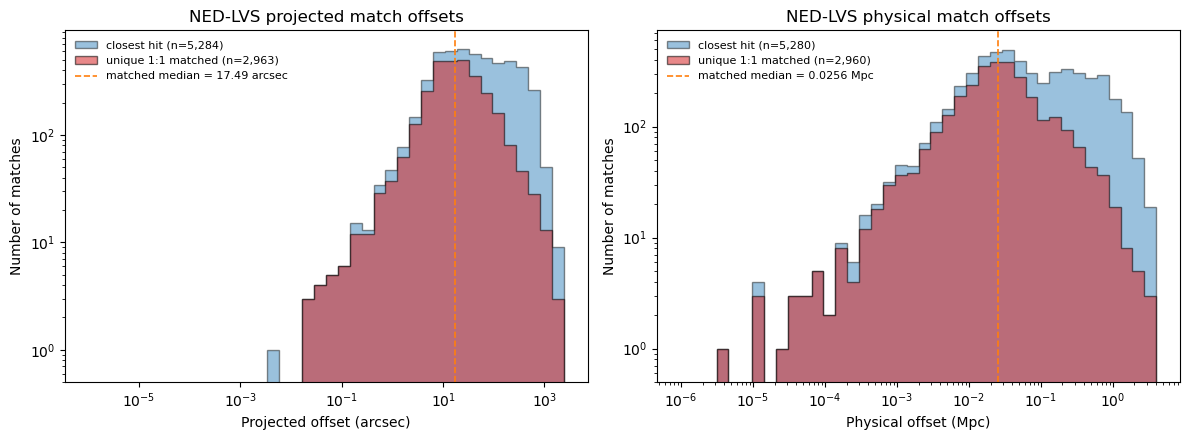

projected: closest n=5,284  unique n=2,963  matched median=17.49 arcsec
physical:  closest n=5,280  unique n=2,960  matched median=0.0256 Mpc


In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

ARCSEC_PER_RAD = 206264.80624709636


def nedlvs_offset_table(
    meta_flags: pd.DataFrame,
    nedlvs_footprint: pd.DataFrame,
    *,
    unique_only: bool = False,
    closest_only: bool = True,
) -> pd.DataFrame:
    """Build per-association projected and physical offsets.

    Uses ``match_RA``/``match_DEC`` when finite (same coords as the matcher),
    else ``RA``/``DEC``. Physical offset is ``sep_rad * DistMpc``.
    """
    flags = meta_flags
    if unique_only:
        flags = flags.loc[flags["n_nedlvs"] == 1]
    if flags.empty or nedlvs_footprint.empty:
        return pd.DataFrame(columns=["sep_arcsec", "DistMpc", "sep_mpc"])

    ref_ra = pd.to_numeric(nedlvs_footprint["RA"], errors="coerce").to_numpy(dtype=float)
    ref_dec = pd.to_numeric(nedlvs_footprint["DEC"], errors="coerce").to_numpy(dtype=float)
    ref_dist = pd.to_numeric(nedlvs_footprint["DistMpc"], errors="coerce").to_numpy(dtype=float)

    records: list[dict[str, float]] = []
    for _, flag in flags.iterrows():
        positions = flag.get("nedlvs_positions", [])
        if positions is None or not hasattr(positions, "__len__") or len(positions) == 0:
            continue
        match_ra = pd.to_numeric(flag.get("match_RA"), errors="coerce")
        match_dec = pd.to_numeric(flag.get("match_DEC"), errors="coerce")
        if not (np.isfinite(match_ra) and np.isfinite(match_dec)):
            match_ra = pd.to_numeric(flag.get("RA"), errors="coerce")
            match_dec = pd.to_numeric(flag.get("DEC"), errors="coerce")
        if not (np.isfinite(match_ra) and np.isfinite(match_dec)):
            continue
        meta_sc = SkyCoord(ra=float(match_ra) * u.deg, dec=float(match_dec) * u.deg)
        pair_rows: list[dict[str, float]] = []
        for pos in positions:
            j = int(pos)
            if j < 0 or j >= len(ref_ra):
                continue
            if not (np.isfinite(ref_ra[j]) and np.isfinite(ref_dec[j])):
                continue
            sep_arcsec = float(
                meta_sc.separation(
                    SkyCoord(ra=ref_ra[j] * u.deg, dec=ref_dec[j] * u.deg)
                ).arcsec
            )
            dist = float(ref_dist[j]) if np.isfinite(ref_dist[j]) else float("nan")
            sep_mpc = (
                sep_arcsec * dist / ARCSEC_PER_RAD
                if np.isfinite(dist) and dist > 0.0
                else float("nan")
            )
            pair_rows.append(
                {"sep_arcsec": sep_arcsec, "DistMpc": dist, "sep_mpc": sep_mpc}
            )
        if not pair_rows:
            continue
        if closest_only:
            records.append(min(pair_rows, key=lambda r: r["sep_arcsec"]))
        else:
            records.extend(pair_rows)
    return pd.DataFrame.from_records(records)


def _positive(arr: np.ndarray) -> np.ndarray:
    out = np.asarray(arr, dtype=float)
    return out[np.isfinite(out) & (out > 0.0)]


def _log_bins(values: np.ndarray, bins: int = 40) -> np.ndarray:
    xmin = max(float(np.min(values)), 1e-6)
    xmax = float(np.max(values))
    if xmax <= xmin:
        xmax = xmin * 10.0
    return np.logspace(np.log10(xmin), np.log10(xmax), int(bins) + 1)


def _set_ylim_from_hists(ax: plt.Axes, count_arrays: list[np.ndarray]) -> None:
    """Tighten log-y limits to the positive histogram bin counts."""
    positive = np.concatenate(
        [c[c > 0] for c in count_arrays if c is not None and np.any(c > 0)]
    )
    if positive.size == 0:
        return
    ymin = max(0.5, 0.5 * float(np.min(positive)))
    ymax = 1.5 * float(np.max(positive))
    if ymax <= ymin:
        ymax = ymin * 10.0
    ax.set_ylim(ymin, ymax)


closest_off = nedlvs_offset_table(meta_flags, result.nedlvs_footprint, unique_only=False)
matched_off = nedlvs_offset_table(meta_flags, result.nedlvs_footprint, unique_only=True)

closest_arc = _positive(closest_off["sep_arcsec"].to_numpy() if not closest_off.empty else [])
matched_arc = _positive(matched_off["sep_arcsec"].to_numpy() if not matched_off.empty else [])
closest_mpc = _positive(closest_off["sep_mpc"].to_numpy() if not closest_off.empty else [])
matched_mpc = _positive(matched_off["sep_mpc"].to_numpy() if not matched_off.empty else [])

if closest_arc.size == 0 and matched_arc.size == 0:
    print("No positive match offsets to plot.")
else:
    fig, (ax_arc, ax_mpc) = plt.subplots(1, 2, figsize=(12, 4.5))

    # --- projected offset (arcsec), log-log ---
    arc_vals = (
        np.concatenate([closest_arc, matched_arc]) if matched_arc.size else closest_arc
    )
    arc_bins = _log_bins(arc_vals)
    arc_counts: list[np.ndarray] = []
    if closest_arc.size:
        c0, _, _ = ax_arc.hist(
            closest_arc,
            bins=arc_bins,
            histtype="stepfilled",
            alpha=0.45,
            edgecolor="k",
            color="C0",
            label=f"closest hit (n={closest_arc.size:,})",
        )
        arc_counts.append(c0)
    if matched_arc.size:
        c1, _, _ = ax_arc.hist(
            matched_arc,
            bins=arc_bins,
            histtype="stepfilled",
            alpha=0.55,
            edgecolor="k",
            color="C3",
            label=f"unique 1:1 matched (n={matched_arc.size:,})",
        )
        arc_counts.append(c1)
    med_src = matched_arc if matched_arc.size else closest_arc
    med_arc = float(np.median(med_src))
    ax_arc.axvline(
        med_arc,
        color="C1",
        ls="--",
        lw=1.2,
        label=f"matched median = {med_arc:.2f} arcsec",
    )
    ax_arc.set_xscale("log")
    ax_arc.set_yscale("log")
    ax_arc.set_xlabel("Projected offset (arcsec)")
    ax_arc.set_ylabel("Number of matches")
    ax_arc.set_title("NED-LVS projected match offsets")
    _set_ylim_from_hists(ax_arc, arc_counts)
    ax_arc.legend(frameon=False, fontsize=8)

    # --- physical offset (Mpc) ---
    mpc_vals = (
        np.concatenate([closest_mpc, matched_mpc]) if matched_mpc.size else closest_mpc
    )
    if mpc_vals.size == 0:
        ax_mpc.text(0.5, 0.5, "No DistMpc for physical offsets", ha="center", va="center")
        ax_mpc.set_axis_off()
    else:
        mpc_bins = _log_bins(mpc_vals)
        mpc_counts: list[np.ndarray] = []
        if closest_mpc.size:
            c0, _, _ = ax_mpc.hist(
                closest_mpc,
                bins=mpc_bins,
                histtype="stepfilled",
                alpha=0.45,
                edgecolor="k",
                color="C0",
                label=f"closest hit (n={closest_mpc.size:,})",
            )
            mpc_counts.append(c0)
        if matched_mpc.size:
            c1, _, _ = ax_mpc.hist(
                matched_mpc,
                bins=mpc_bins,
                histtype="stepfilled",
                alpha=0.55,
                edgecolor="k",
                color="C3",
                label=f"unique 1:1 matched (n={matched_mpc.size:,})",
            )
            mpc_counts.append(c1)
        med_src_mpc = matched_mpc if matched_mpc.size else closest_mpc
        med_mpc = float(np.median(med_src_mpc))
        ax_mpc.axvline(
            med_mpc,
            color="C1",
            ls="--",
            lw=1.2,
            label=f"matched median = {med_mpc:.3g} Mpc",
        )
        ax_mpc.set_xscale("log")
        ax_mpc.set_yscale("log")
        ax_mpc.set_xlabel("Physical offset (Mpc)")
        ax_mpc.set_ylabel("Number of matches")
        ax_mpc.set_title("NED-LVS physical match offsets")
        _set_ylim_from_hists(ax_mpc, mpc_counts)
        ax_mpc.legend(frameon=False, fontsize=8)

    fig.tight_layout()
    plt.show()
    print(
        f"projected: closest n={closest_arc.size:,}  unique n={matched_arc.size:,}  "
        f"matched median={med_arc:.2f} arcsec"
    )
    if matched_mpc.size or closest_mpc.size:
        print(
            f"physical:  closest n={closest_mpc.size:,}  unique n={matched_mpc.size:,}  "
            f"matched median={float(np.median(matched_mpc if matched_mpc.size else closest_mpc)):.3g} Mpc"
        )

## Match browser (table + DSS sky)

Interactive summary of matched meta↔NED-LVS associations. Click a table row to
recenter the DSS optical sky widget on that source. Use the checkbox to toggle a
radio HiPS overlay; pick which LWA HiPS product from the dropdown above the
widget (browser must reach `HIPS_SERVER`, typically via SSH tunnel).

In [13]:
from __future__ import annotations

import astropy.units as u
import numpy as np
import panel as pn
from astropy.coordinates import SkyCoord

from lwa_catalog.viz import (
    apply_aladin_view,
    default_hips_survey,
    fetch_catalog_hips_surveys,
    hips_survey_url,
    make_aladin,
)

pn.extension("tabulator")

# --- sky browser config ---
HIPS_LIST_SERVER = "http://lwacalim09:3005"  # or http://localhost:3005 when SSH-tunneled
HIPS_SERVER = "http://localhost:3005"
DEFAULT_HIPS_SURVEY = "healpix_78MHz_nside2048.hips"
DSS_SURVEY = "CDS/P/DSS2/color"
SKY_FOV_DEG = 1.0
HIPS_VIEW_HEIGHT = 480
TABLE_HEIGHT = 360
TABLE_PAGE_SIZE = 25
RADIO_OVERLAY_OPACITY = 0.55

BROWSE_COLUMNS = [
    "meta_id",
    "RA",
    "DEC",
    "Maj",
    "Min",
    "Peak_flux_78MHz",
    "objname",
    "DistMpc",
    "n_meta",
    "match_source",
    "n_nedlvs",
]


def _as_str(value) -> str:
    if value is None:
        return ""
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    if isinstance(value, float) and not np.isfinite(value):
        return ""
    return str(value)


def build_nedlvs_browse_table(
    metacatalog: pd.DataFrame,
    meta_flags: pd.DataFrame,
    nedlvs_footprint: pd.DataFrame,
    nedlvs_flags: pd.DataFrame,
    *,
    matched_only: bool = True,
) -> pd.DataFrame:
    """Join radio + NED-LVS columns for the match browser table.

    For multi-NED hits, uses the closest host (sky sep to match_RA/DEC or RA/DEC).
    """
    flags = meta_flags.copy()
    if matched_only and "matched" in flags.columns:
        flags = flags.loc[flags["matched"]].copy()
    if flags.empty:
        return pd.DataFrame(columns=BROWSE_COLUMNS)

    meta_cols = [c for c in ("meta_id", "Maj", "Min", "Peak_flux_78MHz") if c in metacatalog.columns]
    meta_by_id = metacatalog.loc[:, meta_cols].drop_duplicates("meta_id").set_index("meta_id")

    ref_ra = pd.to_numeric(nedlvs_footprint["RA"], errors="coerce").to_numpy(dtype=float)
    ref_dec = pd.to_numeric(nedlvs_footprint["DEC"], errors="coerce").to_numpy(dtype=float)
    n_meta_by_pos = (
        pd.to_numeric(nedlvs_flags.set_index("nedlvs_pos")["n_meta"], errors="coerce")
        if (not nedlvs_flags.empty and "nedlvs_pos" in nedlvs_flags.columns)
        else pd.Series(dtype=float)
    )

    records: list[dict] = []
    for _, flag in flags.iterrows():
        positions = flag.get("nedlvs_positions", [])
        if positions is None or not hasattr(positions, "__len__") or len(positions) == 0:
            continue

        match_ra = pd.to_numeric(flag.get("match_RA"), errors="coerce")
        match_dec = pd.to_numeric(flag.get("match_DEC"), errors="coerce")
        if not (np.isfinite(match_ra) and np.isfinite(match_dec)):
            match_ra = pd.to_numeric(flag.get("RA"), errors="coerce")
            match_dec = pd.to_numeric(flag.get("DEC"), errors="coerce")
        if not (np.isfinite(match_ra) and np.isfinite(match_dec)):
            continue

        meta_sc = SkyCoord(ra=float(match_ra) * u.deg, dec=float(match_dec) * u.deg)
        best_pos: int | None = None
        best_sep = float("inf")
        for pos in positions:
            j = int(pos)
            if j < 0 or j >= len(ref_ra):
                continue
            if not (np.isfinite(ref_ra[j]) and np.isfinite(ref_dec[j])):
                continue
            sep = float(
                meta_sc.separation(
                    SkyCoord(ra=ref_ra[j] * u.deg, dec=ref_dec[j] * u.deg)
                ).deg
            )
            if sep < best_sep:
                best_sep = sep
                best_pos = j
        if best_pos is None:
            continue

        ned_row = nedlvs_footprint.iloc[best_pos]
        meta_id = flag.get("meta_id", np.nan)
        maj = min_ = peak78 = np.nan
        if pd.notna(meta_id) and meta_id in meta_by_id.index:
            mrow = meta_by_id.loc[meta_id]
            if isinstance(mrow, pd.DataFrame):
                mrow = mrow.iloc[0]
            maj = pd.to_numeric(mrow.get("Maj"), errors="coerce")
            min_ = pd.to_numeric(mrow.get("Min"), errors="coerce")
            peak78 = pd.to_numeric(mrow.get("Peak_flux_78MHz"), errors="coerce")

        n_meta_val = (
            float(n_meta_by_pos.loc[best_pos])
            if best_pos in n_meta_by_pos.index
            else float("nan")
        )
        records.append(
            {
                "meta_id": meta_id,
                "RA": float(pd.to_numeric(flag.get("RA"), errors="coerce")),
                "DEC": float(pd.to_numeric(flag.get("DEC"), errors="coerce")),
                "Maj": float(maj) if pd.notna(maj) else float("nan"),
                "Min": float(min_) if pd.notna(min_) else float("nan"),
                "Peak_flux_78MHz": float(peak78) if pd.notna(peak78) else float("nan"),
                "objname": _as_str(ned_row.get("objname", "")),
                "DistMpc": float(pd.to_numeric(ned_row.get("DistMpc"), errors="coerce")),
                "n_meta": n_meta_val,
                "match_source": _as_str(flag.get("match_source", "")),
                "n_nedlvs": int(flag.get("n_nedlvs", 0)),
            }
        )

    out = pd.DataFrame.from_records(records, columns=BROWSE_COLUMNS)
    if out.empty:
        return out
    return out.sort_values("Peak_flux_78MHz", ascending=False, na_position="last").reset_index(
        drop=True
    )


browse_df = build_nedlvs_browse_table(
    selected_meta,
    result.meta_flags,
    result.nedlvs_footprint,
    result.nedlvs_flags,
    matched_only=True,
)
print(f"browse table rows (matched): {len(browse_df):,}")
display(browse_df.head())

hips_surveys = fetch_catalog_hips_surveys(
    HIPS_LIST_SERVER,
    layout.root,
    default_survey=DEFAULT_HIPS_SURVEY,
)
hips_default = (
    DEFAULT_HIPS_SURVEY
    if DEFAULT_HIPS_SURVEY in hips_surveys
    else default_hips_survey(hips_surveys, default_survey=DEFAULT_HIPS_SURVEY)
)
print(f"HiPS surveys ({len(hips_surveys)}): {hips_surveys[:5]}{'…' if len(hips_surveys) > 5 else ''}")
print(f"default HiPS = {hips_default}")


class NedlvsMatchBrowser(pn.viewable.Viewer):
    """Tabulator of matched associations + DSS Aladin with optional radio HiPS."""

    def __init__(self, df: pd.DataFrame, *, hips_surveys: list[str], hips_default: str):
        super().__init__()
        self._df = df.reset_index(drop=True).copy()
        self._ready = False

        cols = [c for c in BROWSE_COLUMNS if c in self._df.columns]
        table_df = self._df.loc[:, cols] if cols else self._df

        with pn.config.set(sizing_mode="stretch_width"):
            self._status = pn.pane.Markdown(
                f"**{len(self._df):,}** matched associations — click a row to recenter DSS.",
                sizing_mode="stretch_width",
            )
            self._table = pn.widgets.Tabulator(
                table_df,
                pagination="local",
                page_size=TABLE_PAGE_SIZE,
                height=TABLE_HEIGHT,
                sizing_mode="stretch_width",
                layout="fit_columns",
                show_index=False,
                disabled=True,
                sortable=True,
                selectable=1,
            )
            self._table.param.watch(self._on_table_select, "selection")

            self._hips_survey_w = pn.widgets.Select(
                name="Radio HiPS overlay",
                options=hips_surveys or [hips_default],
                value=hips_default,
                sizing_mode="stretch_width",
            )
            self._overlay_w = pn.widgets.Checkbox(
                name="Show radio HiPS overlay",
                value=False,
            )
            self._hips_status = pn.pane.Markdown(
                f"Base: `{DSS_SURVEY}` · FOV={SKY_FOV_DEG:g}°",
                sizing_mode="stretch_width",
            )

            init_coord = self._default_coord()
            self._aladin = make_aladin(
                survey=DSS_SURVEY,
                target=init_coord,
                fov=float(SKY_FOV_DEG),
                height=HIPS_VIEW_HEIGHT,
            )
            self._hips_view = pn.pane.IPyWidget(
                self._aladin,
                height=HIPS_VIEW_HEIGHT + 20,
                sizing_mode="stretch_width",
            )

            self._hips_survey_w.param.watch(self._on_hips_change, "value")
            self._overlay_w.param.watch(self._on_overlay_toggle, "value")

            self._panel = pn.Column(
                self._status,
                self._table,
                pn.pane.Markdown("### Sky view (DSS + optional radio HiPS)", disable_anchors=True),
                pn.Row(self._hips_survey_w, self._overlay_w, align="end"),
                self._hips_status,
                self._hips_view,
            )

        self._ready = True
        self._apply_radio_overlay()
        if len(self._df):
            self._table.selection = [0]

    def __panel__(self):
        return self._panel

    def _default_coord(self) -> SkyCoord:
        if len(self._df):
            coord = self._row_coord(self._df.iloc[0])
            if coord is not None:
                return coord
        return SkyCoord(ra=180.0 * u.deg, dec=30.0 * u.deg, frame="icrs")

    def _row_coord(self, row: pd.Series) -> SkyCoord | None:
        try:
            ra = float(row["RA"])
            dec = float(row["DEC"])
        except (KeyError, TypeError, ValueError):
            return None
        if not (np.isfinite(ra) and np.isfinite(dec)):
            return None
        return SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")

    def _radio_hips_url(self) -> str:
        return hips_survey_url(str(self._hips_survey_w.value), base=HIPS_SERVER)

    def _apply_radio_overlay(self) -> None:
        url = self._radio_hips_url()
        try:
            self._aladin.overlay_survey = url
            self._aladin.overlay_survey_opacity = (
                float(RADIO_OVERLAY_OPACITY) if self._overlay_w.value else 0.0
            )
        except Exception as exc:
            self._hips_status.object = f"**Radio HiPS update failed:** `{exc}`"
            return
        state = "on" if self._overlay_w.value else "off"
        self._hips_status.object = (
            f"Base: `{DSS_SURVEY}` · radio overlay **{state}** "
            f"(`{self._hips_survey_w.value}`, opacity="
            f"{RADIO_OVERLAY_OPACITY if self._overlay_w.value else 0.0:g})"
        )

    def _on_hips_change(self, _event=None) -> None:
        if not self._ready:
            return
        self._apply_radio_overlay()

    def _on_overlay_toggle(self, _event=None) -> None:
        if not self._ready:
            return
        self._apply_radio_overlay()

    def _on_table_select(self, _event=None) -> None:
        if not self._ready or not self._table.selection:
            return
        idx = int(self._table.selection[0])
        if idx < 0 or idx >= len(self._df):
            return
        row = self._df.iloc[idx]
        coord = self._row_coord(row)
        if coord is None:
            self._hips_status.object = f"Row {idx}: non-finite RA/DEC — cannot recenter."
            return
        apply_aladin_view(self._aladin, coord, float(SKY_FOV_DEG))
        meta_id = row.get("meta_id", "?")
        obj = row.get("objname", "")
        overlay_state = "on" if self._overlay_w.value else "off"
        self._hips_status.object = (
            f"Centered on meta_id={meta_id}"
            + (f" / {obj}" if obj else "")
            + f" · FOV={SKY_FOV_DEG:g}° · base `{DSS_SURVEY}`"
            + f" · radio overlay **{overlay_state}**"
        )


if browse_df.empty:
    print("No matched associations to browse.")
else:
    nedlvs_browser = NedlvsMatchBrowser(
        browse_df,
        hips_surveys=hips_surveys,
        hips_default=hips_default,
    )
    display(nedlvs_browser)

browse table rows (matched): 5,284


,meta_id,RA,DEC,Maj,Min,Peak_flux_78MHz,objname,DistMpc,n_meta,match_source,n_nedlvs
0,6,76.180447,38.110657,0.113997,0.102132,118.061570,WISEA J050431.73+375555.4,134.459686,1.0,LWA,15
1,21,49.953594,41.499267,0.133621,0.100815,109.224394,NGC 1275:[PFC2012] UCD25,69.080376,2.0,LWA,972
2,19,123.403674,48.214336,0.130414,0.080385,94.505092,WISEA J081339.89+481413.7,580.247620,1.0,LWA,473
3,8,6.332600,64.157417,0.173293,0.133005,92.538504,WISEA J002422.77+632954.8,296.888184,1.0,LWA,1
4,11,333.605607,-17.025235,0.180301,0.082539,82.940734,3C 444,539.215820,1.0,VLSSR,1


HiPS surveys (17): ['healpix_18MHz_nside2048.hips', 'healpix_23MHz_nside2048.hips', 'healpix_27MHz_nside2048.hips', 'healpix_32MHz_nside2048.hips', 'healpix_36MHz_nside2048.hips']…
default HiPS = healpix_78MHz_nside2048.hips


NedlvsMatchBrowser(name='NedlvsMatchBrowser00151')

## NED-LVS recovery vs distance (unique matches only)

For each `DistMpc` threshold, recovery is the fraction of bijective NED-LVS matches (exactly one galaxy per meta row, and one meta row per galaxy) at or closer than that distance.

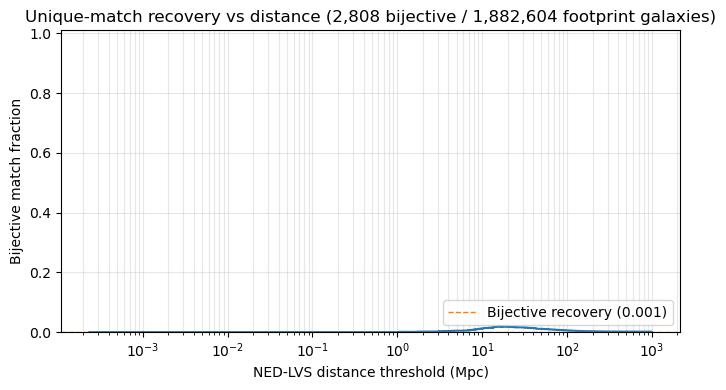

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from lwa_catalog.analyze import select_bijective_nedlvs_flags

bijective_ned = select_bijective_nedlvs_flags(result.meta_flags, result.nedlvs_flags)
bijective_pos = set(bijective_ned["nedlvs_pos"].astype(int).tolist())

footprint_dist = pd.to_numeric(result.nedlvs_footprint["DistMpc"], errors="coerce")
ok = np.isfinite(footprint_dist.to_numpy(dtype=float)) & (footprint_dist > 0)
dist_all = footprint_dist.loc[ok].to_numpy()
matched = np.array(
    [1 if pos in bijective_pos else 0 for pos in footprint_dist.loc[ok].index],
    dtype=int,
)
order = np.argsort(dist_all)
dist_all = dist_all[order]
matched = matched[order]

suffix_matched = np.cumsum(matched)
suffix_total = np.arange(1, len(dist_all) + 1, dtype=float)
recovery = suffix_matched / suffix_total
overall = float(suffix_matched[-1] / suffix_total[-1]) if len(dist_all) else float("nan")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dist_all, recovery, drawstyle="steps-post")
ax.axhline(
    overall,
    color="C1",
    ls="--",
    lw=1,
    label=f"Bijective recovery ({overall:.3f})",
)
ax.set_xscale("log")
ax.set_xlabel("NED-LVS distance threshold (Mpc)")
ax.set_ylabel("Bijective match fraction")
ax.set_ylim(0, 1.01)
ax.set_title(
    f"Unique-match recovery vs distance ({int(suffix_matched[-1]):,} bijective / "
    f"{len(dist_all):,} footprint galaxies)"
)
ax.legend(loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## SFR–radio luminosity relation (unique matches only)

Uses only meta rows with exactly one NED-LVS association (`n_nedlvs == 1`). For each pair with NED-LVS SFR and redshift, the highest-frequency positive LWA flux (preferring `Total_flux_{band}`, falling back to peak) is converted to `nu*L_nu` and plotted versus SFR.


In [ ]:
unique_meta = select_unique_nedlvs_matches(result.meta_flags)
print(
    f"unique meta matches: {len(unique_meta):,} / {len(result.meta_flags):,} matched rows"
)

sfr_radio = build_sfr_radio_luminosity_table(
    selected_meta,
    result.nedlvs_footprint,
    result.meta_flags,
    unique_only=True,
)
print(f"unique pairs with SFR + radio luminosity: {len(sfr_radio)}")
display(sfr_radio.head())

unique meta matches: 2,963 / 167,618 matched rows
unique pairs with SFR + radio luminosity: 2639


,meta_id,objname,z,SFR,SFR_column,radio_band,radio_freq_hz,Flux_jy,L_nu_erg_s_hz,nuL_nu_erg_s
0,8,b'WISEA J002422.77+632954.8',0.065662,2.592291,SFR_W4,VLASS,3.000000e+09,0.013991,1.559612e+30,4.678836e+39
1,11,b'3C 444',0.115300,3.256423,SFR_W4,82MHz,8.200000e+07,156.038336,5.733198e+34,4.701223e+42
2,145126,b'WISEA J192057.06+435331.8',0.054000,0.297144,SFR_W4,78MHz,7.800000e+07,12.244527,9.081794e+32,7.083799e+40
3,39385,b'WISEA J094709.21+073725.4',0.141324,5.402092,SFR_hybrid,NVSS,1.400000e+09,0.003400,1.939991e+30,2.715987e+39
4,36,b'3C 430',0.055545,0.922177,SFR_W4,NVSS,1.400000e+09,7.802600,6.136491e+32,8.591087e+41


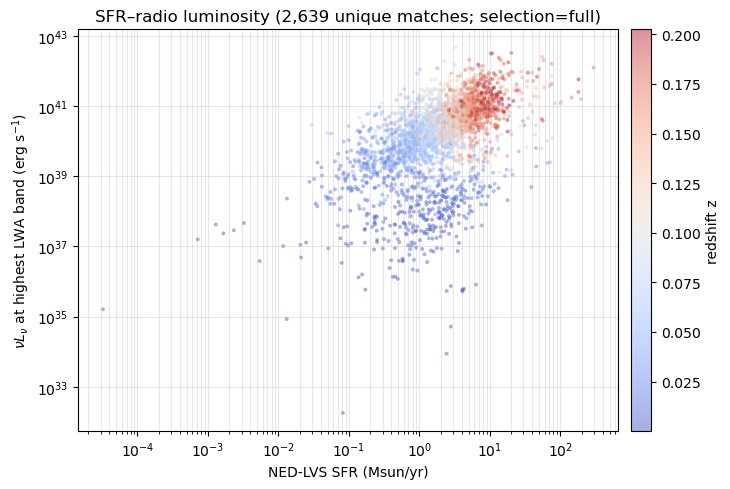

In [ ]:
if sfr_radio.empty:
    print("No SFR–radio pairs to plot.")
else:
    fig, ax = plt.subplots(figsize=(7.5, 5))
    sc = ax.scatter(
        sfr_radio["SFR"],
        sfr_radio["nuL_nu_erg_s"],
        c=sfr_radio["z"],
        cmap="coolwarm",
        s=8,
        alpha=0.45,
        edgecolors="none",
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("redshift z")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("NED-LVS SFR (Msun/yr)")
    ax.set_ylabel(r"$\nu L_\nu$ at highest LWA band (erg s$^{-1}$)")
    ax.set_title(
        f"SFR–radio luminosity ({len(sfr_radio):,} unique matches; "
        f"selection={METACATALOG_SELECTION})"
    )
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Metacatalog Maj vs NED-LVS projected size (unique matches only)

Compares PyBDSF major-axis FWHM (`Maj`, degrees → arcsec) with the NED-LVS galaxy projected diameter (`Diam_arcsec`). Only bijective meta↔NED pairs are shown.

unique pairs with Maj + NED-LVS Diam: 2,753


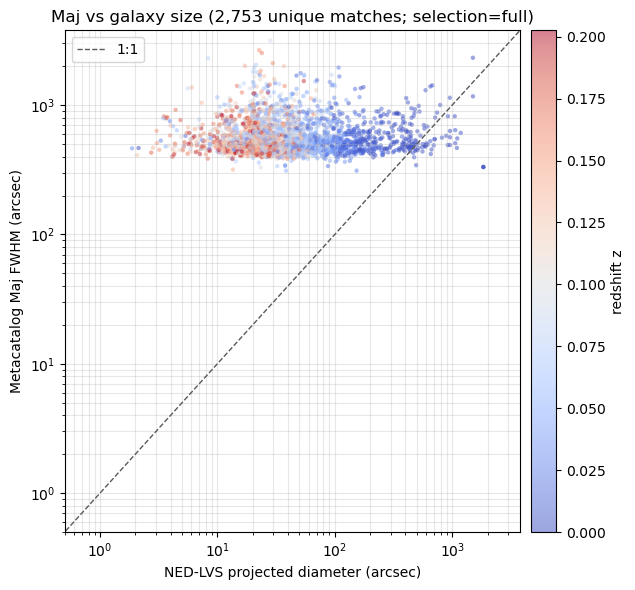

In [ ]:
unique_flags = select_unique_nedlvs_matches(result.meta_flags)
meta_by_id = selected_meta.set_index("meta_id", drop=False)

size_records: list[dict] = []
for _, flag in unique_flags.iterrows():
    if not bool(flag.get("matched", False)):
        continue
    positions = flag.get("nedlvs_positions", [])
    if len(positions) != 1:
        continue

    meta_id = flag["meta_id"]
    if meta_id not in meta_by_id.index:
        continue
    meta_row = meta_by_id.loc[meta_id]
    if isinstance(meta_row, pd.DataFrame):
        meta_row = meta_row.iloc[0]

    maj_deg = pd.to_numeric(meta_row.get("Maj"), errors="coerce")
    ned_row = result.nedlvs_footprint.iloc[int(positions[0])]
    diam_arcsec = pd.to_numeric(ned_row.get("Diam_arcsec"), errors="coerce")
    if not (
        np.isfinite(maj_deg)
        and float(maj_deg) > 0.0
        and np.isfinite(diam_arcsec)
        and float(diam_arcsec) > 0.0
    ):
        continue

    size_records.append(
        {
            "meta_id": meta_id,
            "Maj_arcsec": float(maj_deg) * 3600.0,
            "Diam_arcsec": float(diam_arcsec),
            "z": pd.to_numeric(ned_row.get("z"), errors="coerce"),
        }
    )

size_pairs = pd.DataFrame.from_records(size_records)
print(f"unique pairs with Maj + NED-LVS Diam: {len(size_pairs):,}")

if size_pairs.empty:
    print("No size pairs to plot.")
else:
    lim = np.nanmax(
        [size_pairs["Maj_arcsec"].max(), size_pairs["Diam_arcsec"].max()]
    )
    lim = max(float(lim) * 1.2, 1.0)

    fig, ax = plt.subplots(figsize=(6.5, 6))
    sc = ax.scatter(
        size_pairs["Diam_arcsec"],
        size_pairs["Maj_arcsec"],
        c=size_pairs["z"],
        cmap="coolwarm",
        s=10,
        alpha=0.5,
        edgecolors="none",
    )
    ax.plot([0.0, lim], [0.0, lim], color="0.35", ls="--", lw=1, label="1:1")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.5, lim)
    ax.set_ylim(0.5, lim)
    ax.set_xlabel("NED-LVS projected diameter (arcsec)")
    ax.set_ylabel("Metacatalog Maj FWHM (arcsec)")
    ax.set_title(
        f"Maj vs galaxy size ({len(size_pairs):,} unique matches; "
        f"selection={METACATALOG_SELECTION})"
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("redshift z")
    ax.legend(loc="upper left")
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Cumulative 82 MHz total flux

Plots the empirical cumulative distribution of positive `Total_flux_82MHz` on the selected MHz subband metacatalog.

Total_flux_82MHz: 132,993 positive finite sources (full @ metacatalog_healpix_IdTR-0.75s_subband)


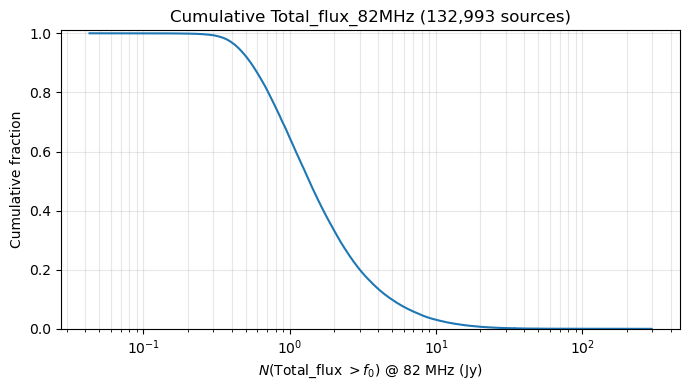

In [ ]:
FLUX_82_COL = "Total_flux_82MHz"
flux_source_label = f"{METACATALOG_SELECTION} @ {CATALOG_DIR.name}"

if FLUX_82_COL not in selected_meta.columns:
    print(f"{FLUX_82_COL} not available for the selected metacatalog.")
else:
    flux = pd.to_numeric(selected_meta[FLUX_82_COL], errors="coerce").to_numpy(dtype=float)
    flux = np.sort(flux[np.isfinite(flux) & (flux > 0)])
    n_flux = len(flux)
    print(f"{FLUX_82_COL}: {n_flux:,} positive finite sources ({flux_source_label})")

    if n_flux == 0:
        print("No positive 82 MHz flux values to plot.")
    else:
        cum_frac = (np.arange(1, n_flux + 1, dtype=float) / n_flux)[::-1]

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(flux, cum_frac, drawstyle="steps-post", color="C0")
        ax.set_xscale("log")
        ax.set_xlabel(r"$N$(Total_flux $> f_0$) @ 82 MHz (Jy)")
        ax.set_ylabel("Cumulative fraction")
        ax.set_ylim(0, 1.01)
        ax.set_title(f"Cumulative Total_flux_82MHz ({n_flux:,} sources)")
        ax.grid(True, which="both", alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
## MilliQUAS optical AGN / quasar cross-match

Load [MilliQUAS](https://quasars.org/milliquas.htm) (Flesch) from `MILLIQUAS_PATH`
(`/fast/claw/milliquas.dat` — FITS table despite the `.dat` suffix) and
cross-match to the same quality-filtered `selected_meta` used for NED-LVS.

Matching uses `associate_catalogs` with LWA beam radius on the metacatalog side
and a fixed 1″ optical radius on the MilliQUAS side (LWA `BMAJ` dominates).

**Class columns** from the MilliQUAS `Type` field:

| Column | Meaning |
| --- | --- |
| `MilliQUAS_Type` | Raw type code (e.g. `Q`, `AX`, `QR2X`) |
| `MilliQUAS_class_primary` | Primary optical class letter: `Q`/`A`/`B`/`K`/`N`/`S` |
| `MilliQUAS_class_label` | Human-readable primary class |
| `MilliQUAS_has_radio` / `_has_xray` / `_has_double_lobes` | Association flags (`R` / `X` / `2` in Type) |

Also attaches name, redshift, R/B photometry, and citation fields. Multi-match
rows prefer a radio-associated hit, then closest on sky.

Controlled by `RUN_MILLIQUAS_CROSSMATCH` (independent of NED-LVS).

In [ ]:
if not RUN_MILLIQUAS_CROSSMATCH:
    print("Skipping MilliQUAS load (RUN_MILLIQUAS_CROSSMATCH=False)")
else:
    if "selected_meta" not in globals() or not isinstance(selected_meta, pd.DataFrame):
        raise RuntimeError("selected_meta missing — run the metacatalog load cells first")

    milliquas = load_milliquas_catalog(MILLIQUAS_PATH)
    print(f"MilliQUAS rows: {len(milliquas):,}")
    print(f"RA range: {milliquas['RA'].min():.2f} .. {milliquas['RA'].max():.2f}")
    print(f"DEC range: {milliquas['DEC'].min():.2f} .. {milliquas['DEC'].max():.2f}")
    print("\nPrimary class counts:")
    display(milliquas["class_primary"].value_counts().sort_index())
    print("\nSample (first 12 rows):")
    display(
        milliquas[
            [
                c
                for c in [
                    "Name",
                    "RA",
                    "DEC",
                    "Type",
                    "class_primary",
                    "class_label",
                    "has_radio",
                    "has_xray",
                    "has_double_lobes",
                    "z",
                    "Rmag",
                    "Bmag",
                ]
                if c in milliquas.columns
            ]
        ].head(12)
    )

    milliquas_result = match_catalog_to_milliquas(
        selected_meta,
        milliquas=milliquas,
        config=milliquas_config,
    )
    print(summarize_milliquas_match(milliquas_result))

In [ ]:
if not RUN_MILLIQUAS_CROSSMATCH:
    print("Skipping MilliQUAS attach / class QA (RUN_MILLIQUAS_CROSSMATCH=False)")
else:
    mq_meta_flags = milliquas_result.meta_flags
    mq_ref_flags = milliquas_result.milliquas_flags
    mq_fp = milliquas_result.milliquas_footprint

    print("MilliQUAS hits per meta (value_counts):")
    display(mq_meta_flags["n_milliquas"].value_counts().sort_index().head(20))

    milliquas_meta = attach_milliquas_to_metacatalog(
        selected_meta,
        mq_fp,
        mq_meta_flags,
    )
    matched = milliquas_meta.loc[milliquas_meta["n_milliquas"] >= 1]
    print(f"\nAttached matches: {len(matched):,} / {len(milliquas_meta):,}")

    preview_cols = [
        c
        for c in [
            "meta_id",
            "RA",
            "DEC",
            "n_milliquas",
            "sep_arcsec_MilliQUAS",
            "MilliQUAS_Name",
            "MilliQUAS_Type",
            "MilliQUAS_class_primary",
            "MilliQUAS_class_label",
            "MilliQUAS_has_radio",
            "MilliQUAS_has_xray",
            "MilliQUAS_has_double_lobes",
            "MilliQUAS_z",
            "MilliQUAS_Rmag",
            "MilliQUAS_Bmag",
        ]
        if c in milliquas_meta.columns
    ]
    print(f"\nMatched rows with class columns (first 20 of {len(matched):,}):")
    display(matched[preview_cols].head(20))

    unique_ids = select_unique_milliquas_matches(mq_meta_flags)
    if "meta_id" in milliquas_meta.columns and "meta_id" in unique_ids.columns:
        unique_attached = milliquas_meta.loc[
            milliquas_meta["meta_id"].isin(unique_ids["meta_id"])
        ]
    else:
        unique_attached = milliquas_meta.loc[milliquas_meta["n_milliquas"] == 1]
    print(f"\nUnique 1:1 class counts ({len(unique_attached):,} rows):")
    display(milliquas_class_counts(unique_attached))

    oversplit = mq_ref_flags.loc[mq_ref_flags["oversplit"]]
    print(f"\nMilliQUAS over-split rows (first 20 of {len(oversplit):,}):")
    display(oversplit.head(20))

## MilliQUAS class pie (unique matches only)

Primary optical class (`MilliQUAS_class_primary`) for LWA rows with exactly one
MilliQUAS counterpart (`n_milliquas == 1`). Labels follow Flesch MilliQUAS Note (3):
`Q` QSO, `A` AGN, `B` BL Lac, `K` NLQSO, `N` NLAGN, `S` star/candidate.

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt

if not RUN_MILLIQUAS_CROSSMATCH:
    print("Skipping MilliQUAS class pie (RUN_MILLIQUAS_CROSSMATCH=False)")
elif "milliquas_meta" not in globals():
    print("milliquas_meta missing — run the MilliQUAS attach cell first")
else:
    unique_attached = milliquas_meta.loc[milliquas_meta["n_milliquas"] == 1]
    counts = milliquas_class_counts(unique_attached)
    if counts.empty:
        print("No unique MilliQUAS class labels to plot.")
    else:
        labels = [
            f"{code}: {MILLIQUAS_CLASS_LABELS.get(code, code)}" for code in counts.index
        ]
        fig, ax = plt.subplots(figsize=(7.5, 5))
        ax.pie(
            counts.to_numpy(),
            labels=labels,
            autopct="%1.1f%%",
            startangle=90,
            textprops={"fontsize": 8},
        )
        ax.set_title(
            f"MilliQUAS primary class ({len(unique_attached):,} unique matches; "
            f"selection={METACATALOG_SELECTION})"
        )
        plt.tight_layout()
        plt.show()
        display(counts.rename("n").to_frame())